In [70]:
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from mplsoccer import VerticalPitch
from statsbombpy import sb


sys.path.append("../")
from xThreat import xThreat

In [71]:
n_x = 16
n_y = 12

In [72]:
xT_true_16x12 = xThreat.load_from_pickle(f'../0-model-storage/xt-full-data-n_x{n_x}-n_y{n_y}.pickle')

In [73]:
df_euros = pd.read_parquet('../1-data-preparation/data-storage/xThreat_datav3_euros2020.parquet')
df_euros.head()

,x,y,possession_kept,possession,possession_length,chain_length,previous_deleted,match_id,id,period,...,shot_outcome,shot_statsbomb_xg,pass_height,under_pressure,next_type,next_x,next_y,next_under_pressure,next_team_id,next_player_id
index,,,,,,,,,,,,,,,,,,,,,
2088,13.8250,6.375,True,3,0,0,True,3788741,4cbd1088-1580-43f5-8b09-58efabb753ff,1,...,None,NaN,None,NaN,Pass,2.8875,10.795,NaN,914.0,6954.0
9,2.8875,10.795,True,3,2,1,False,3788741,bfcfd5ad-1dda-44c9-9f3d-9b33b59983a6,1,...,None,NaN,Ground Pass,NaN,Carry,6.9125,30.770,NaN,914.0,7036.0
2089,6.9125,30.770,True,3,3,2,False,3788741,58ef2997-552a-4d3e-854a-cf863f9f5b71,1,...,None,NaN,None,NaN,Pass,7.9625,33.065,NaN,914.0,7036.0
10,7.9625,33.065,True,3,4,3,False,3788741,14604dfa-65b1-40c0-a11e-7c6b037806c0,1,...,None,NaN,Ground Pass,NaN,Carry,17.2375,40.715,NaN,914.0,7173.0
2090,17.2375,40.715,True,3,5,4,False,3788741,5eae5d7a-59cb-42e0-bfc0-c5a2e80493ee,1,...,None,NaN,None,NaN,Pass,25.2000,42.415,NaN,914.0,7173.0


In [74]:
df_euros.describe()

,x,y,possession,possession_length,chain_length,match_id,period,player_id,shot_statsbomb_xg,under_pressure,next_x,next_y,next_under_pressure,next_team_id,next_player_id
count,92654.000000,92654.000000,92654.000000,92654.000000,92654.000000,9.265400e+04,92654.000000,92654.000000,619.000000,20416.0,92654.000000,92654.000000,20407.0,92654.000000,92654.000000
mean,51.333875,33.650458,89.303743,12.809172,8.329559,3.790811e+06,1.574417,10128.393291,0.140505,1.0,51.345598,33.648096,1.0,886.433538,10129.786906
std,23.291350,19.858639,55.170866,13.628198,10.101545,2.917399e+03,0.660055,8483.507971,0.196433,0.0,23.296198,19.857529,0.0,273.628451,8485.351214
min,0.350000,0.085000,2.000000,0.000000,0.000000,3.788741e+06,1.000000,2954.000000,0.004871,1.0,0.350000,0.085000,1.0,768.000000,2954.000000
25%,35.087500,16.171250,43.000000,3.000000,1.000000,3.788754e+06,1.000000,4870.000000,0.035180,1.0,35.175000,16.235000,1.0,772.000000,4870.000000
50%,50.925000,33.405000,85.000000,8.000000,5.000000,3.788767e+06,2.000000,6954.000000,0.060380,1.0,50.925000,33.405000,1.0,785.000000,6954.000000
75%,68.250000,51.085000,131.000000,18.000000,12.000000,3.794688e+06,2.000000,11514.000000,0.139786,1.0,68.250000,51.085000,1.0,912.000000,11514.000000
max,104.650000,67.915000,275.000000,119.000000,103.000000,3.795506e+06,5.000000,73852.000000,0.963011,1.0,104.650000,67.915000,1.0,2358.000000,73852.000000


<!-- # Find playing time per player and most played position -->

In [ ]:
player_ids = df_euros['player_id'].unique().tolist()

In [24]:
# # Get all competitions and find UEFA Euro 2020
# competitions = sb.competitions()
# euro_2020 = competitions[
#     (competitions['competition_name'] == 'UEFA Euro') & (competitions['season_name'] == '2020')
# ]
# competition_id = euro_2020.iloc[0]['competition_id']
# season_id = euro_2020.iloc[0]['season_id']

# # Get all matches
# matches = sb.matches(competition_id=competition_id, season_id=season_id)
# match_ids = matches['match_id'].tolist()

# # Dictionary to store player minutes
# player_minutes = {}

# # Loop through each match
# for match_id in match_ids:
#     events = sb.events(match_id)

#     # Get match duration (accounting for extra time)
#     max_minute = events['minute'].max()

#     # Track player substitutions
#     player_in_times = {}  # {player_id: entry_minute}
#     player_out_times = {} # {player_id: exit_minute}

#     for _, event in events.iterrows():
#         if event['type'] == 'Substitution':
#             player_off = event['player']
#             player_on = event['substitution_replacement']
#             minute = event['minute']

#             if player_off:
#                 player_out_times[player_off] = minute
#             if player_on:
#                 player_in_times[player_on] = minute

#     # Calculate minutes for all players
#     for player in events['player'].dropna().unique():
#         start_minute = player_in_times.get(player, 0)  # Defaults to starting lineup (0 min)
#         end_minute = player_out_times.get(player, max_minute)  # Defaults to full game

#         minutes_played = end_minute - start_minute
#         player_minutes[player] = player_minutes.get(player, 0) + minutes_played

# # Convert to DataFrame
# players_df = pd.DataFrame(player_minutes.items(), columns=['Player', 'Minutes'])

# # Filter for players with at least 300 minutes
# filtered_players = players_df[players_df['Minutes'] >= 300]
# filtered_players

In [75]:
position_mapping = {
    'Goalkeeper': 'Goalkeeper',
    'Right Back': 'Defender', 'Left Back': 'Defender', 'Center Back': 'Defender', 'Right Center Back': 'Defender', 'Left Center Back': 'Defender',
    'Right Wing Back': 'Defender', 'Left Wing Back': 'Defender', 
    'Center Defensive Midfield': 'Midfielder', 'Left Defensive Midfield': 'Midfielder', 'Right Defensive Midfield': 'Midfielder',
    'Central Midfield': 'Midfielder', 
    'Center Attacking Midfield': 'Midfielder', 'Right Attacking Midfield': 'Midfielder', 'Left Attacking Midfield': 'Midfielder',
    'Left Center Forward': 'Attacker', 'Right Center Forward': 'Attacker',
    'Right Midfield': 'Midfielder', 'Left Midfield': 'Midfielder', 'Right Center Midfield': 'Midfielder', 'Left Center Midfield': 'Midfielder',
    'Right Wing': 'Attacker', 'Left Wing': 'Attacker', 'Center Forward': 'Attacker', 'Second Striker': 'Attacker'
}

In [80]:

# Get all competitions and find UEFA Euro 2020
competitions = sb.competitions()
euro_2020 = competitions[
    (competitions['competition_name'] == 'UEFA Euro') & (competitions['season_name'] == '2020')
]
competition_id = euro_2020.iloc[0]['competition_id']
season_id = euro_2020.iloc[0]['season_id']

# Get all matches
matches = sb.matches(competition_id=competition_id, season_id=season_id)
match_ids = matches['match_id'].tolist()

# Dictionary to store player minutes
player_minutes = {}

# Dictionary to store player positions
player_positions = {}

# Dictionary to store player names for each id
player_ids = {}

# Loop through each match
for match_id in match_ids:
    events = sb.events(match_id)
    
    # Get match duration (accounting for extra time)
    max_minute = events['minute'].max()

    # Track player substitutions
    player_in_times = {}  # {player_name: entry_minute}
    player_out_times = {} # {player_name: exit_minute}

    for _, event in events.iterrows():
        if event['type'] == 'Substitution':
            player_off = event['player']
            player_on = event['substitution_replacement']
            minute = event['minute']

            if player_off:
                player_out_times[player_off] = minute
            if player_on:
                player_in_times[player_on] = minute

    # Calculate minutes for all players
    for player in events['player'].dropna().unique():
        start_minute = player_in_times.get(player, 0)  # Defaults to starting lineup (0 min)
        end_minute = player_out_times.get(player, max_minute)  # Defaults to full game

        minutes_played = end_minute - start_minute
        player_minutes[player] = player_minutes.get(player, 0) + minutes_played

    # Get lineup data for this match
    lineup_data = sb.lineups(match_id)

    # Extract player positions (lineup_data is a dictionary of DataFrames)
    for team_name, lineup_df in lineup_data.items():
        for _, player in lineup_df.iterrows():
            player_name = player['player_name']
            player_id = player['player_id']
            player_ids[player_name] = player_id

            game_player_positions = player_positions.get(player_name, {'Goalkeeper': 0, 'Defender': 0, 'Midfielder': 0, 'Attacker': 0})
            for position in player['positions']:
                game_player_positions[position_mapping[position['position']]] += 1
                
            player_positions[player_name] = game_player_positions

# Convert minutes to DataFrame
players_df = pd.DataFrame(player_minutes.items(), columns=['Player', 'Minutes'])

player_ids = pd.DataFrame(player_ids.items(), columns = ['Player', 'player_id'])

# Convert positions to DataFrame
player_names = player_positions.keys()
goalkeeper, defender, midfielder, attacker = [], [], [], []
for player_name in player_names:
    goalkeeper.append(player_positions[player_name]['Goalkeeper'])
    defender.append(player_positions[player_name]['Defender'])
    midfielder.append(player_positions[player_name]['Midfielder'])
    attacker.append(player_positions[player_name]['Attacker'])

positions_df = pd.DataFrame({
    'Player': player_names,
    'goalkeeper': goalkeeper,
    'defender': defender,
    'midfielder': midfielder,
    'attacker': attacker,
})
positions_df["main_position"] = positions_df[["goalkeeper", "defender", "midfielder", "attacker"]].idxmax(axis=1)


# Merge DataFrames
players_df = players_df.merge(positions_df, on='Player', how='left')
players_df = players_df.merge(player_ids, on='Player', how='left')

# Filter for players with at least 300 minutes
filtered_players = players_df[players_df['Minutes'] >= 300]

filtered_players.head()

,Player,Minutes,goalkeeper,defender,midfielder,attacker,main_position,player_id
0,Álvaro Borja Morata Martín,455,0,0,0,8,attacker,3477
1,Pau Francisco Torres,395,0,10,0,0,defender,6892
2,Aymeric Laporte,658,0,12,0,0,defender,4353
3,Jordi Alba Ramos,581,0,6,0,0,defender,5211
5,Jorge Resurrección Merodio,483,0,0,6,0,midfielder,5199


We check the distribution of the played minutes. We can see that most players played less than 300 minutes. This is as expected as not that many games are played by most teams during the Euros.

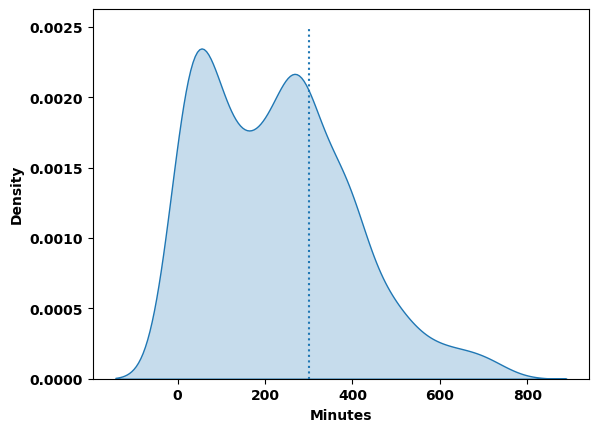

In [78]:
ax = sns.kdeplot(data=players_df, x='Minutes', fill=True)
ax.plot([300, 300], [0,0.0025], ":")

<!-- # Filter on players with at least 300 minutes -->

In [81]:
filtered_player_ids = filtered_players['player_id']
filtered_player_ids

0       3477
1       6892
2       4353
3       5211
5       5199
       ...  
358    20005
359     5632
362     3509
363     3176
437     5476
Name: player_id, Length: 146, dtype: int64

## Filter the data on the 

In [32]:
# mask = df_euros['player_id'].isin(filtered_player_ids)
# df_euros_filtered = df_euros[mask].copy()
# df_euros_filtered

<!-- # Visualisation of the distribution -->

In [33]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Count occurrences of each player_id
# player_counts = df_euros_filtered['player_id'].value_counts()

# # Plot KDE
# plt.figure(figsize=(8, 5))
# sns.histplot(player_counts, fill=True, stat='density')
# plt.xlabel('Number of events')
# plt.ylabel('Density')
# plt.title('KDE Plot of Player Events')
# plt.show()


In [34]:
# df_euros_filtered['shot'] = ~df_euros_filtered['shot_outcome'].isna()
# df_euros_filtered['goal'] = df_euros_filtered['shot_outcome'] == 'Goal'

<!-- ## True model 16x12 -->

In [35]:
# df_euros_filtered = xT_true_16x12.quantify_action_quality(df_euros_filtered)
# df_positive = df_euros_filtered[df_euros_filtered['action_xT'] > 0]
# df_positive = df_positive.merge(filtered_players[['player_id', 'Minutes', 'main_position']], on='player_id', how='left')
# df_positive['action_xT_sum'] = df_positive['action_xT']
# df_positive['action_xT'] = df_positive['action_xT'] / df_positive['Minutes'] * 90

In [36]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Group by player_id and sum action_xT
# player_xT_sum = df_positive.groupby('player_id')['action_xT'].sum()

# # Create KDE plot
# plt.figure(figsize=(8, 5))
# sns.histplot(player_xT_sum, fill=True, stat='density')
# plt.xlabel('Total action_xT')
# plt.ylabel('Density')
# plt.title('KDE Plot of Total action_xT per Player')
# plt.show()

# # Create a beeswarm plot
# plt.figure(figsize=(8, 5))
# sns.swarmplot(x=player_xT_sum, orient='h', size=5)
# plt.xlabel('Total action_xT')
# plt.title('Beeswarm Plot of Total action_xT per Player')
# plt.show()

# # Alternative: Create a quantile plot (ECDF)
# plt.figure(figsize=(8, 5))
# sns.ecdfplot(player_xT_sum)
# plt.xlabel('Total action_xT')
# plt.ylabel('Cumulative Probability')
# plt.title('Quantile (ECDF) Plot of Total action_xT per Player')
# plt.show()


In [37]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Group by player_id and sum action_xT
# player_xT_sum = df_positive.groupby('player_id')['action_xT'].sum()

# # Create KDE plot
# plt.figure(figsize=(8, 5))
# sns.histplot(player_xT_sum, fill=True, stat='density')
# plt.xlabel('Total action_xT')
# plt.ylabel('Density')
# plt.title('KDE Plot of Total action_xT per Player per 90')
# plt.show()

# # Create a beeswarm plot
# plt.figure(figsize=(8, 5))
# sns.swarmplot(x=player_xT_sum, orient='h', size=5)
# plt.xlabel('Total action_xT')
# plt.title('Beeswarm Plot of Total action_xT per Player per 90')
# plt.show()

# # Alternative: Create a quantile plot (ECDF)
# plt.figure(figsize=(8, 5))
# sns.ecdfplot(player_xT_sum)
# plt.xlabel('Total action_xT')
# plt.ylabel('Cumulative Probability')
# plt.title('Quantile (ECDF) Plot of Total action_xT per Player')
# plt.show()


In [38]:
# import numpy as np

# # Merge player names into the player_xT_sum DataFrame
# player_xT_df = player_xT_sum.reset_index().merge(filtered_players[['player_id', 'Player']], on='player_id')

# # Sort values for annotation
# player_xT_df = player_xT_df.sort_values('action_xT')

# # Select some key points for annotation: min, max, and quartiles
# key_indices = [0, 1, 2, len(player_xT_df) // 4, len(player_xT_df) // 2, 3 * len(player_xT_df) // 4, len(player_xT_df) - 4, len(player_xT_df) - 3, len(player_xT_df) - 2, len(player_xT_df) - 1]
# key_players = player_xT_df.iloc[key_indices]

# # Create beeswarm plot
# plt.figure(figsize=(12, 6))
# ax = sns.swarmplot(x=player_xT_df['action_xT'], orient='h', size=5)

# # Annotate selected points with lines and staggered text positions
# y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
# for i, (_, row) in enumerate(key_players.iterrows()):
#     plt.plot([row['action_xT'], row['action_xT']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
#     plt.text(row['action_xT'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

# plt.xlabel('Total action_xT')
# plt.title('Beeswarm Plot of Total action_xT per 90 per Player 16x12 model')
# plt.show()


<!-- ## True model 64x48 -->

In [39]:
# df_euros_filtered_64x48 = xT_true_64x48.quantify_action_quality(df_euros_filtered)
# df_positive_64x48 = df_euros_filtered_64x48[df_euros_filtered_64x48['action_xT'] > 0]
# df_positive_64x48 = df_positive_64x48.merge(filtered_players[['player_id', 'Minutes', 'main_position']], on='player_id', how='left')
# df_positive_64x48['action_xT_sum'] = df_positive_64x48['action_xT']
# df_positive_64x48['action_xT'] = df_positive_64x48['action_xT'] / df_positive_64x48['Minutes'] * 90

In [40]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Group by player_id and sum action_xT
# player_xT_sum_64x48 = df_positive_64x48.groupby('player_id')['action_xT'].sum()

# # Create KDE plot
# plt.figure(figsize=(8, 5))
# sns.histplot(player_xT_sum_64x48, fill=True, stat='density')
# plt.xlabel('Total action_xT')
# plt.ylabel('Density')
# plt.title('KDE Plot of Total action_xT per Player')
# plt.show()

# # Create a beeswarm plot
# plt.figure(figsize=(8, 5))
# sns.swarmplot(x=player_xT_sum_64x48, orient='h', size=5)
# plt.xlabel('Total action_xT')
# plt.title('Beeswarm Plot of Total action_xT per Player')
# plt.show()

# # Alternative: Create a quantile plot (ECDF)
# plt.figure(figsize=(8, 5))
# sns.ecdfplot(player_xT_sum_64x48)
# plt.xlabel('Total action_xT')
# plt.ylabel('Cumulative Probability')
# plt.title('Quantile (ECDF) Plot of Total action_xT per Player')
# plt.show()


In [41]:
# import numpy as np

# # Merge player names into the player_xT_sum DataFrame
# player_xT_df_64x48 = player_xT_sum_64x48.reset_index().merge(filtered_players[['player_id', 'Player']], on='player_id')

# # Sort values for annotation
# player_xT_df_64x48 = player_xT_df_64x48.sort_values('action_xT')

# # Select some key points for annotation: min, max, and quartiles
# key_indices = [0, 1, 2, len(player_xT_df_64x48) // 4, len(player_xT_df_64x48) // 2, 3 * len(player_xT_df_64x48) // 4, len(player_xT_df_64x48) - 4, len(player_xT_df_64x48) - 3, len(player_xT_df_64x48) - 2, len(player_xT_df_64x48) - 1]
# key_players = player_xT_df_64x48.iloc[key_indices]

# # Create beeswarm plot
# plt.figure(figsize=(12, 6))
# ax = sns.swarmplot(x=player_xT_df_64x48['action_xT'], orient='h', size=5)

# # Annotate selected points with lines and staggered text positions
# y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
# for i, (_, row) in enumerate(key_players.iterrows()):
#     plt.plot([row['action_xT'], row['action_xT']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
#     plt.text(row['action_xT'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

# plt.xlabel('Total action_xT')
# plt.title('Beeswarm Plot of Total action_xT per 90 per Player 64x48 model')
# plt.show()


<!-- ## True model 32x24 -->

In [42]:
# df_euros_filtered_32x24 = xT_true_32x24.quantify_action_quality(df_euros_filtered)
# df_positive_32x24 = df_euros_filtered_32x24[df_euros_filtered_32x24['action_xT'] > 0]
# df_positive_32x24 = df_positive_32x24.merge(filtered_players[['player_id', 'Minutes', 'main_position']], on='player_id', how='left')
# df_positive_32x24['action_xT_sum'] = df_positive_32x24['action_xT']
# df_positive_32x24['action_xT'] = df_positive_32x24['action_xT'] / df_positive_32x24['Minutes'] * 90

In [43]:
# import pandas as pd
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Group by player_id and sum action_xT
# player_xT_sum_32x24 = df_positive_32x24.groupby('player_id')['action_xT'].sum()

# # Create KDE plot
# plt.figure(figsize=(8, 5))
# sns.histplot(player_xT_sum_32x24, fill=True, stat='density')
# plt.xlabel('Total action_xT')
# plt.ylabel('Density')
# plt.title('KDE Plot of Total action_xT per Player')
# plt.show()

# # Create a beeswarm plot
# plt.figure(figsize=(8, 5))
# sns.swarmplot(x=player_xT_sum_32x24, orient='h', size=5)
# plt.xlabel('Total action_xT')
# plt.title('Beeswarm Plot of Total action_xT per Player')
# plt.show()

# # Alternative: Create a quantile plot (ECDF)
# plt.figure(figsize=(8, 5))
# sns.ecdfplot(player_xT_sum_32x24)
# plt.xlabel('Total action_xT')
# plt.ylabel('Cumulative Probability')
# plt.title('Quantile (ECDF) Plot of Total action_xT per Player')
# plt.show()

In [44]:

# import numpy as np

# # Merge player names into the player_xT_sum DataFrame
# player_xT_df_32x24 = player_xT_sum_32x24.reset_index().merge(filtered_players[['player_id', 'Player']], on='player_id')

# # Sort values for annotation
# player_xT_df_32x24 = player_xT_df_32x24.sort_values('action_xT')

# # Select some key points for annotation: min, max, and quartiles
# key_indices = [0, 1, 2, len(player_xT_df_32x24) // 4, len(player_xT_df_32x24) // 2, 3 * len(player_xT_df_32x24) // 4, len(player_xT_df_32x24) - 4, len(player_xT_df_32x24) - 3, len(player_xT_df_32x24) - 2, len(player_xT_df_32x24) - 1]
# key_players = player_xT_df_32x24.iloc[key_indices]

# # Create beeswarm plot
# plt.figure(figsize=(12, 6))
# ax = sns.swarmplot(x=player_xT_df_32x24['action_xT'], orient='h', size=5)

# # Annotate selected points with lines and staggered text positions
# y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
# for i, (_, row) in enumerate(key_players.iterrows()):
#     plt.plot([row['action_xT'], row['action_xT']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
#     plt.text(row['action_xT'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

# plt.xlabel('Total action_xT')
# plt.title('Beeswarm Plot of Total action_xT per 90 per Player 32x24 model')
# plt.show()


<!-- ## Look at difference between 16x12 and 64x48 -->

In [45]:
# combined_player_xT_df = player_xT_df.rename(columns={'action_xT': 'action_xT_16x12'}).merge(player_xT_df_64x48.drop(columns=['Player']).rename(columns={'action_xT': 'action_xT_64x48'}), on='player_id')
# combined_player_xT_df = combined_player_xT_df.merge(player_xT_df_32x24.drop(columns=['Player']).rename(columns={'action_xT': 'action_xT_32x24'}), on='player_id')
# combined_player_xT_df['diff_xT'] = combined_player_xT_df['action_xT_64x48'] - combined_player_xT_df['action_xT_16x12']
# combined_player_xT_df

In [46]:
# import numpy as np

# # Sort values for annotation
# combined_player_xT_df = combined_player_xT_df.sort_values('diff_xT')

# # Select some key points for annotation: min, max, and quartiles
# key_indices = [0, 1, 2, len(player_xT_df) // 4, len(combined_player_xT_df) // 2, 3 * len(combined_player_xT_df) // 4, len(combined_player_xT_df) - 4, len(combined_player_xT_df) - 3, len(combined_player_xT_df) - 2, len(combined_player_xT_df) - 1]
# key_players = combined_player_xT_df.iloc[key_indices]

# # Create beeswarm plot
# plt.figure(figsize=(12, 6))
# ax = sns.swarmplot(x=combined_player_xT_df['diff_xT'], orient='h', size=5)

# # Annotate selected points with lines and staggered text positions
# y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
# for i, (_, row) in enumerate(key_players.iterrows()):
#     plt.plot([row['diff_xT'], row['diff_xT']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
#     plt.text(row['diff_xT'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

# plt.xlabel('Difference in xT: (xT 64x48) - (xT 16x12)')
# plt.title('The difference in xT values per 90 between the 16x12 model and the 64x48 model.')
# plt.show()


In [47]:
# xT_true_16x12.plot_xThreat()
# xT_true_32x24.plot_xThreat()
# xT_true_64x48.plot_xThreat()

<!-- # Resampled models -->

In [48]:
# df_errors = pd.read_csv('../2-calculate-values/bootstrap_errors_normal_xthreat.csv').rename(columns={'sample_size': 'N'})
# df_errors['M'] = df_errors['n_x'] * df_errors['n_y']
# df_errors['1/sqrt(N)'] = 1/np.sqrt(df_errors['N'])
# df_errors['Mlog(M)/sqrt(N)'] = df_errors['M']*np.log(df_errors['M'])*df_errors['1/sqrt(N)']

# # Make the norm a dimension independent norm
# for col in df_errors.columns.tolist():
#     if '1_norm' in col:
#         df_errors[col] = df_errors[col]/df_errors['M']
#     if ' 2_norm' in col:
#         df_errors[col] = df_errors[col]/np.sqrt(df_errors['M'])

In [49]:
# df_errors

In [50]:
# df_errors[(df_errors['n_x'] == 16) & (df_errors['N'] == 630_000) & (df_errors['i_bootstrap'] == 900)][['xT_error_1_norm', 'xT_error_inf_norm', 'Mlog(M)/sqrt(N)']]

In [51]:
# df_errors[(df_errors['n_x'] == 64) & (df_errors['N'] == 630_000) & (df_errors['i_bootstrap'] == 906)][['xT_error_1_norm', 'xT_error_inf_norm', 'Mlog(M)/sqrt(N)']]

In [52]:
# df_errors[(df_errors['n_x'] == 32) & (df_errors['N'] == 4_000_000) & (df_errors['i_bootstrap'] == 900)][['xT_error_1_norm', 'xT_error_inf_norm', 'Mlog(M)/sqrt(N)']]

<!-- ## Resampled 16x12 (630 000 events) -->

In [53]:
# xT_resampled_16x12 = xThreat.load_from_pickle('../0-model-storage/xt-N630000-n_x16-n_y12-i_bootstrap900-random_state1806942.pickle')

In [54]:
# xT_resampled_16x12.plot_pitch_heatmap(xT_resampled_16x12.xT - xT_true_16x12.xT)

<!-- ## Resampled 64x48 (630 000 events) -->

In [55]:
# xT_resampled_64x48 = xThreat.load_from_pickle('../0-model-storage/xt-N630000-n_x64-n_y48-i_bootstrap906-random_state5334948.pickle')

In [56]:
# xT_resampled_64x48.plot_pitch_heatmap(xT_resampled_64x48.xT - xT_true_64x48.xT)

<!-- ## Resampled 64x48 (630 000 events) -->

In [57]:
# xT_resampled_32x24 = xThreat.load_from_pickle('../0-model-storage/xt-N4000000-n_x32-n_y24-i_bootstrap900-random_state6352942.pickle')

In [58]:
# xT_resampled_32x24.plot_pitch_heatmap(xT_resampled_32x24.xT - xT_true_32x24.xT)

<!-- ## Calculate resampled xT values -->

In [59]:
# df_euros_filtered_resampled_16x12 = xT_resampled_16x12.quantify_action_quality(df_euros_filtered)
# df_positive_resampled_16x12 = df_euros_filtered_resampled_16x12[df_euros_filtered_resampled_16x12['action_xT'] > 0]
# df_positive_resampled_16x12 = df_positive_resampled_16x12.merge(filtered_players[['player_id', 'Minutes', 'main_position']], on='player_id', how='left')
# df_positive_resampled_16x12['action_xT_sum'] = df_positive_resampled_16x12['action_xT']
# df_positive_resampled_16x12['action_xT'] = df_positive_resampled_16x12['action_xT'] / df_positive_resampled_16x12['Minutes'] * 90

# player_xT_df_resampled_16x12 = pd.DataFrame(df_positive_resampled_16x12.groupby('player_id')['action_xT'].sum()).rename(columns={'action_xT': 'action_xT_resampled_16x12'})
# player_xT_df_resampled_16x12

In [60]:
# df_euros_filtered_resampled_64x48 = xT_resampled_64x48.quantify_action_quality(df_euros_filtered)
# df_positive_resampled_64x48 = df_euros_filtered_resampled_64x48[df_euros_filtered_resampled_64x48['action_xT'] > 0]
# df_positive_resampled_64x48 = df_positive_resampled_64x48.merge(filtered_players[['player_id', 'Minutes', 'main_position']], on='player_id', how='left')
# df_positive_resampled_64x48['action_xT_sum'] = df_positive_resampled_64x48['action_xT']
# df_positive_resampled_64x48['action_xT'] = df_positive_resampled_64x48['action_xT'] / df_positive_resampled_64x48['Minutes'] * 90
# player_xT_df_resampled_64x48 = pd.DataFrame(df_positive_resampled_64x48.groupby('player_id')['action_xT'].sum()).rename(columns={'action_xT': 'action_xT_resampled_64x48'})
# player_xT_df_resampled_64x48

In [61]:
# df_euros_filtered_resampled_32x24 = xT_resampled_32x24.quantify_action_quality(df_euros_filtered)
# df_positive_resampled_32x24 = df_euros_filtered_resampled_32x24[df_euros_filtered_resampled_32x24['action_xT'] > 0]
# df_positive_resampled_32x24 = df_positive_resampled_32x24.merge(filtered_players[['player_id', 'Minutes', 'main_position']], on='player_id', how='left')
# df_positive_resampled_32x24['action_xT_sum'] = df_positive_resampled_32x24['action_xT']
# df_positive_resampled_32x24['action_xT'] = df_positive_resampled_32x24['action_xT'] / df_positive_resampled_32x24['Minutes'] * 90
# player_xT_df_resampled_32x24 = pd.DataFrame(df_positive_resampled_32x24.groupby('player_id')['action_xT'].sum()).rename(columns={'action_xT': 'action_xT_resampled_32x24'})
# player_xT_df_resampled_32x24

In [62]:
# combined_player_xT_df

In [63]:
# combined_player_xT_df = combined_player_xT_df.merge(player_xT_df_resampled_16x12, on='player_id', how='left')
# combined_player_xT_df = combined_player_xT_df.merge(player_xT_df_resampled_64x48, on='player_id', how='left')
# combined_player_xT_df = combined_player_xT_df.merge(player_xT_df_resampled_32x24, on='player_id', how='left')

In [64]:
# combined_player_xT_df

In [65]:
# combined_player_xT_df['diff_xT_16x12'] = combined_player_xT_df['action_xT_16x12'] - combined_player_xT_df['action_xT_resampled_16x12']
# combined_player_xT_df['diff_xT_32x24'] = combined_player_xT_df['action_xT_32x24'] - combined_player_xT_df['action_xT_resampled_32x24']
# combined_player_xT_df['diff_xT_64x48'] = combined_player_xT_df['action_xT_64x48'] - combined_player_xT_df['action_xT_resampled_64x48']
# combined_player_xT_df

In [66]:
# import numpy as np

# # Sort values for annotation
# combined_player_xT_df = combined_player_xT_df.sort_values('diff_xT')

# # Select some key points for annotation: min, max, and quartiles
# key_indices = [0, 1, 2, len(player_xT_df) // 4, len(combined_player_xT_df) // 2, 3 * len(combined_player_xT_df) // 4, len(combined_player_xT_df) - 4, len(combined_player_xT_df) - 3, len(combined_player_xT_df) - 2, len(combined_player_xT_df) - 1]
# key_players = combined_player_xT_df.iloc[key_indices]

# # Create beeswarm plot
# plt.figure(figsize=(12, 6))
# ax = sns.swarmplot(x=combined_player_xT_df['diff_xT'], orient='h', size=5)

# # Annotate selected points with lines and staggered text positions
# y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
# for i, (_, row) in enumerate(key_players.iterrows()):
#     plt.plot([row['diff_xT'], row['diff_xT']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
#     plt.text(row['diff_xT'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

# plt.xlabel('Difference in xT: (xT 64x48) - (xT 16x12)')
# plt.title('The difference in xT values between the 16x12 model and the 64x48 model.')
# plt.show()


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Sort values for annotation
# combined_player_xT_df = combined_player_xT_df.sort_values('diff_xT_16x12')

# # Select some key points for annotation: min, max, and quartiles
# key_indices = [0, 1, 2, len(combined_player_xT_df) // 4, len(combined_player_xT_df) // 2, 3 * len(combined_player_xT_df) // 4, len(combined_player_xT_df) - 4, len(combined_player_xT_df) - 3, len(combined_player_xT_df) - 2, len(combined_player_xT_df) - 1]
# key_players = combined_player_xT_df.iloc[key_indices]

# # Create subplots
# fig, axes = plt.subplots(1, 2, figsize=(15, 6))  # 1 row, 2 columns


# # Create beeswarm plot
# sns.swarmplot(x=combined_player_xT_df['diff_xT_16x12'], orient='h', size=5, ax=axes[0])

# # Annotate selected points with lines and staggered text positions
# y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
# for i, (_, row) in enumerate(key_players.iterrows()):
#     axes[0].plot([row['diff_xT_16x12'], row['diff_xT_16x12']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
#     axes[0].text(row['diff_xT_16x12'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

# axes[0].set_xlabel('Difference in xT: (xT_true 16x12) - (xT resampled 16x12)')
# axes[0].set_title('The difference in xT values between the true and resampled 16x12 model.')


# # Sort values for annotation
# combined_player_xT_df = combined_player_xT_df.sort_values('diff_xT_64x48')
# # Create beeswarm plot
# sns.swarmplot(x=combined_player_xT_df['diff_xT_64x48'], orient='h', size=5, ax=axes[1])

# # Annotate selected points with lines and staggered text positions
# y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
# for i, (_, row) in enumerate(key_players.iterrows()):
#     axes[1].plot([row['diff_xT_64x48'], row['diff_xT_64x48']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
#     axes[1].text(row['diff_xT_64x48'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

# axes[1].set_xlabel('Difference in xT: (xT_true 64x48) - (xT resampled 64x48)')
# axes[1].set_title('The difference in xT values between the true and resampled 64x48 model.')

# # Adjust layout for better spacing
# plt.tight_layout()

# # Show the plot
# plt.show()


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Sort values for annotation
# combined_player_xT_df = combined_player_xT_df.sort_values('diff_xT_16x12')

# # Select some key points for annotation: min, max, and quartiles
# key_indices = [0, 1, 2, len(combined_player_xT_df) // 4, len(combined_player_xT_df) // 2, 3 * len(combined_player_xT_df) // 4, len(combined_player_xT_df) - 4, len(combined_player_xT_df) - 3, len(combined_player_xT_df) - 2, len(combined_player_xT_df) - 1]
# key_players = combined_player_xT_df.iloc[key_indices]

# # Create subplots
# fig, axes = plt.subplots(1, 3, figsize=(22.5, 6))  # 1 row, 2 columns

# # Create beeswarm plot
# sns.swarmplot(x=combined_player_xT_df['diff_xT_16x12'], orient='h', size=5, ax=axes[0])

# # Annotate selected points with lines and staggered text positions
# y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
# for i, (_, row) in enumerate(key_players.iterrows()):
#     axes[0].plot([row['diff_xT_16x12'], row['diff_xT_16x12']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
#     axes[0].text(row['diff_xT_16x12'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

# axes[0].set_xlabel('Difference in xT: (xT_true 16x12) - (xT resampled 16x12)')
# axes[0].set_title('The difference in xT values between the true and resampled 16x12 model.')


# # Sort values for annotation
# combined_player_xT_df = combined_player_xT_df.sort_values('diff_xT_32x24')
# # Create beeswarm plot
# sns.swarmplot(x=combined_player_xT_df['diff_xT_32x24'], orient='h', size=5, ax=axes[1])

# # Annotate selected points with lines and staggered text positions
# y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
# for i, (_, row) in enumerate(key_players.iterrows()):
#     axes[1].plot([row['diff_xT_32x24'], row['diff_xT_32x24']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
#     axes[1].text(row['diff_xT_32x24'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

# axes[1].set_xlabel('Difference in xT: (xT_true 32x24) - (xT resampled 32x24)')
# axes[1].set_title('The difference in xT values between the true and resampled 32x24 model.')


# # Sort values for annotation
# combined_player_xT_df = combined_player_xT_df.sort_values('diff_xT_64x48')
# # Create beeswarm plot
# sns.swarmplot(x=combined_player_xT_df['diff_xT_64x48'], orient='h', size=5, ax=axes[2])

# # Annotate selected points with lines and staggered text positions
# y_positions = np.linspace(-0.2, 0.2, len(key_players))  # Staggered y-positions for better visibility
# for i, (_, row) in enumerate(key_players.iterrows()):
#     axes[2].plot([row['diff_xT_64x48'], row['diff_xT_64x48']], [0, y_positions[i]], 'k--', alpha=0.6)  # Guiding line
#     axes[2].text(row['diff_xT_64x48'], y_positions[i], row['Player'], fontsize=10, verticalalignment='center', color='black')

# axes[2].set_xlabel('Difference in xT: (xT_true 64x48) - (xT resampled 64x48)')
# axes[2].set_title('The difference in xT values between the true and resampled 64x48 model.')

# # Adjust layout for better spacing
# plt.tight_layout()

# # Show the plot
# plt.show()

In [ ]:
# 